# Brain Tumor Classification

## Import necessary Libraries 

In [130]:
import os
import random
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random
from IPython.display import Image
import imutils   

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

import keras
import tensorflow.keras as K

import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, ImageDataGenerator, array_to_img, img_to_array
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Conv2D, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import imutils    

In [131]:
'''
Set working directory to the Project folder
'''
os.chdir('/Users/abbyeast/Desktop/Fall 24/ML/Project')
print(os.getcwd())  # Verify if it changed

/Users/abbyeast/Desktop/Fall 24/ML/Project


## Data

In [132]:
# Training set
datagen = ImageDataGenerator(rotation_range=10,
                             height_shift_range=0.2,
                             horizontal_flip=True,
                             validation_split=0.2)

train_data = datagen.flow_from_directory('Data/Crop-Training/',
                                         target_size=(240, 240),
                                         batch_size=32,
                                         class_mode='categorical',
                                         subset='training')

valid_data = datagen.flow_from_directory('Data/Crop-Training/',
                                         target_size=(240, 240),
                                         batch_size=32,
                                         class_mode='categorical',
                                         subset='validation')

# Test set
test_datagen = ImageDataGenerator()

test_data = datagen.flow_from_directory('Data/Crop-Testing/',
                                         target_size=(240, 240),
                                        class_mode='categorical',
                                        shuffle=False)
                                        

Found 6867 images belonging to 4 classes.
Found 1715 images belonging to 4 classes.
Found 1705 images belonging to 4 classes.


## Model Architecture

In [ ]:
#build the model
from tensorflow.keras.applications import EfficientNetB1
weights_path = 'EfficientNetModel/efficientnetb1_notop.h5'
effnet = EfficientNetB1(weights=weights_path, 
                        include_top=False, 
                        input_shape=(240, 240, 3))

model = effnet.output
model = GlobalAveragePooling2D()(model)
model = Dropout(0.5)(model)
model = Dense(4, activation='softmax')(model)
model = Model(inputs=effnet.input, 
              outputs=model)

#get summary()
model.summary()

## Compile Model

In [134]:
#compile model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#define checkpoint
checkpoint = ModelCheckpoint('model.keras', 
                             monitor='val_accuracy',
                             save_best_only=True,
                             mode='auto',
                             verbose=1)

#early stopping
earlystop = EarlyStopping(monitor='val_accuracy',
                          patience=5,
                          mode='auto',
                          verbose=1)

#reduce learning rate
reduce_lr = ReduceLROnPlateau(monitor = 'val_accuracy', 
                              factor = 0.3, 
                              patience = 2, 
                              min_delta = 0.001,
                              mode='auto',
                              verbose=1)

## Model Training and Model Evaluation

In [136]:
%%time

#train the model
history = model.fit(train_data,
                    epochs = 15,
                    validation_data=valid_data,
                    verbose=1,
                    callbacks=[checkpoint, earlystop, reduce_lr])

Epoch 1/15
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8657 - loss: 0.4092

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_accuracy improved from -inf to 0.89096, saving model to model.keras
215/215 ━━━━━━━━━━━━━━━━━━━━ 458s 2s/step - accuracy: 0.8659 - loss: 0.4086 - val_accuracy: 0.8910 - val_loss: 0.2949 - learning_rate: 1.0000e-04
Epoch 2/15
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9637 - loss: 0.1082
Epoch 2: val_accuracy improved from 0.89096 to 0.95394, saving model to model.keras
215/215 ━━━━━━━━━━━━━━━━━━━━ 494s 2s/step - accuracy: 0.9637 - loss: 0.1082 - val_accuracy: 0.9539 - val_loss: 0.1286 - learning_rate: 1.0000e-04
Epoch 3/15
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9866 - loss: 0.0505
Epoch 3: val_accuracy improved from 0.95394 to 0.98134, saving model to model.keras
215/215 ━━━━━━━━━━━━━━━━━━━━ 466s 2s/step - accuracy: 0.9866 - loss: 0.0505 - val_accuracy: 0.9813 - val_loss: 0.0514 - learning_rate: 1.0000e-04
Epoch 4/15
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9894 - loss: 0.0349
Epoch 4: val_accuracy improved from 0.98134 to 0.98950, s

In [160]:
model.save('tr_efficient_net.keras')

## Model Evaluation

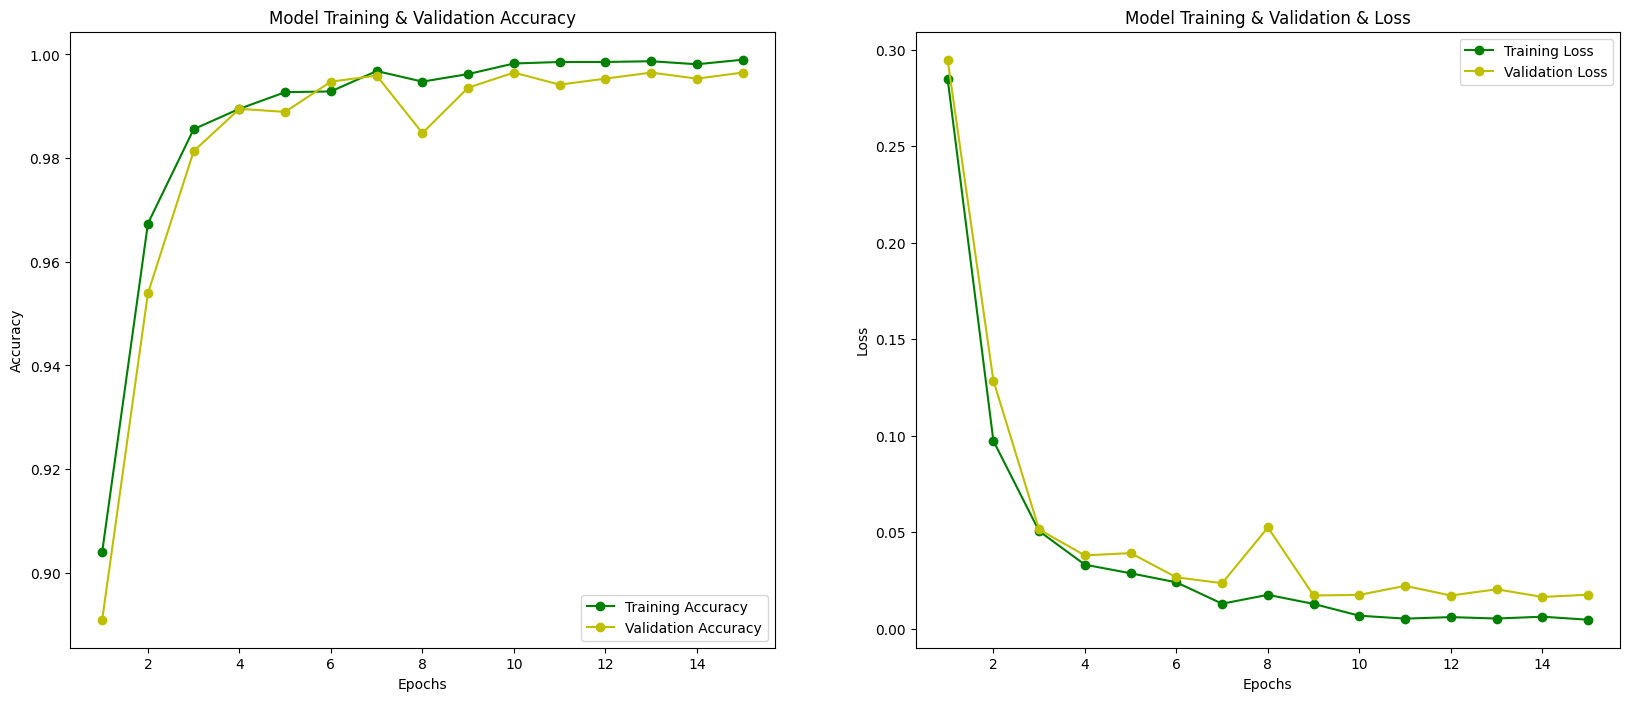

In [155]:
fig , ax = plt.subplots(1,2)
fig.set_size_inches(20, 8)

train_acc = history.history['accuracy']
train_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

epochs = range(1, len(train_acc) + 1)

ax[0].plot(epochs , train_acc , 'g-o' , label = 'Training Accuracy')
ax[0].plot(epochs , val_acc , 'y-o' , label = 'Validation Accuracy')
ax[0].set_title('Model Training & Validation Accuracy')
ax[0].legend(loc = 'lower right')
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Accuracy")

ax[1].plot(epochs , train_loss , 'g-o' , label = 'Training Loss')
ax[1].plot(epochs , val_loss , 'y-o' , label = 'Validation Loss')
ax[1].set_title('Model Training & Validation & Loss')
ax[1].legend()
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Loss")

plt.show()

In [138]:
print('Train accuracy & loss:', model.evaluate(train_data))
print('\n')
print('Test accuracy & loss:', model.evaluate(test_data))

215/215 ━━━━━━━━━━━━━━━━━━━━ 77s 356ms/step - accuracy: 1.0000 - loss: 5.8250e-04
Train accuracy & loss: [0.0006766141741536558, 0.9998543858528137]


54/54 ━━━━━━━━━━━━━━━━━━━━ 19s 349ms/step - accuracy: 0.9105 - loss: 0.6391
Test accuracy & loss: [0.33886417746543884, 0.9513196349143982]


In [156]:
#define labels for testing
y_test = test_data.classes

#make prediction
yhat_test = np.argmax(model.predict(test_data), axis=1)

54/54 ━━━━━━━━━━━━━━━━━━━━ 19s 350ms/step


In [140]:
y_test

array([0, 0, 0, ..., 3, 3, 3], dtype=int32)

In [141]:
yhat_test

array([0, 0, 2, ..., 3, 3, 3])

In [157]:
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize = False,
                          title = 'Confusion Matrix',
                          cmap = plt.cm.Blues):
    
    plt.figure(figsize = (6,6))
    plt.imshow(cm, interpolation = 'nearest', cmap = cmap)
    plt.title(title)
    plt.colorbar()
    plt.grid(False)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation = 90)
    plt.yticks(tick_marks, classes)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis = 1)[:, np.newaxis]

    thresh = cm.max() / 2.
    cm = np.round(cm,2)
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 fontsize = 12,
                 horizontalalignment = "center",
                 color = "white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

[[332  32  35   1]
 [  0 420   0   1]
 [  0   0 510   0]
 [  0   7   5 362]]


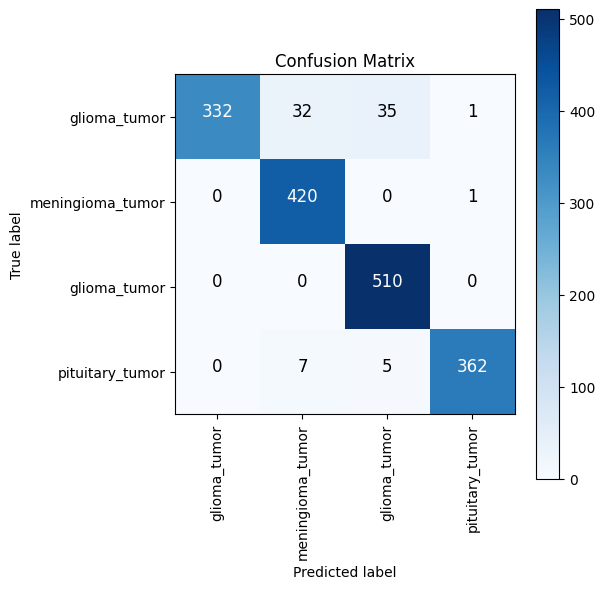

In [158]:
#get confusion matrix
cm = confusion_matrix(y_test, yhat_test)
print(cm)

#plot
plot_confusion_matrix(cm, ['glioma_tumor', 'meningioma_tumor', 'glioma_tumor', 'pituitary_tumor'], normalize=False)

In [144]:
#get classification report
print(classification_report(y_test, yhat_test))

              precision    recall  f1-score   support

           0       1.00      0.83      0.91       400
           1       0.90      1.00      0.95       421
           2       0.94      1.00      0.97       510
           3       1.00      0.97      0.98       374

    accuracy                           0.95      1705
   macro avg       0.96      0.95      0.95      1705
weighted avg       0.96      0.95      0.95      1705



## Obtaining Predictions on Test Images

In [150]:
import PIL
import numpy as np
import os

class_dict = {0: 'glioma_tumor',
              1: 'meningioma_tumor',
              2: 'no_tumor',
              3: 'pituitary_tumor'}

prediction = []
original = []
image = []

# Loop through test data
for i in os.listdir('Data/Crop-Testing/'):
    # Skip hidden files
    if i.startswith('.'):
        continue

    for item in os.listdir(os.path.join('Data/Crop-Testing', i)):
        # Skip hidden files
        if item.startswith('.'):
            continue

        # Load the image
        img = PIL.Image.open(os.path.join('Data/Crop-Testing', i, item))

        
        # Resize the image to (240, 240)
        img = img.resize((240, 240))

        image.append(img)

        # Expand dimensions to match the input shape for the model
        img = np.expand_dims(img, axis=0)

        # Predict
        predict = model.predict(img)

        # Get the index of the highest value in the prediction
        predict = np.argmax(predict)

        # Append the predicted class and original class to lists
        prediction.append(class_dict[predict])
        original.append(i)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━

In [151]:
#test accuracy 
score = accuracy_score(original, prediction)
print("Test Accuracy : {}".format(score))

Test Accuracy : 0.955425219941349


In [152]:
print(classification_report(original, prediction))

                  precision    recall  f1-score   support

    glioma_tumor       1.00      0.83      0.91       400
meningioma_tumor       0.91      1.00      0.95       421
        no_tumor       0.94      1.00      0.97       510
 pituitary_tumor       0.99      0.98      0.99       374

        accuracy                           0.96      1705
       macro avg       0.96      0.95      0.95      1705
    weighted avg       0.96      0.96      0.95      1705



[[332  36  31   1]
 [  0 420   0   1]
 [  0   0 510   0]
 [  0   7   0 367]]


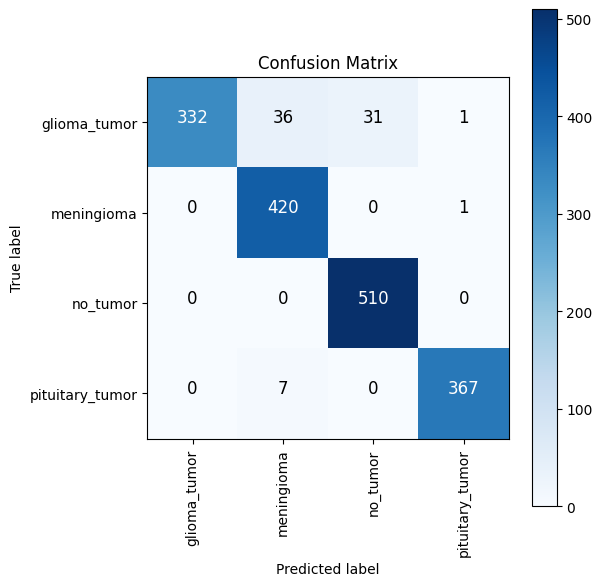

In [153]:
#get confusion matrix
cm = confusion_matrix(original, prediction)
print(cm)

#plot
plot_confusion_matrix(cm, ['glioma_tumor', 'meningioma', 'no_tumor', 'pituitary_tumor'], normalize=False)

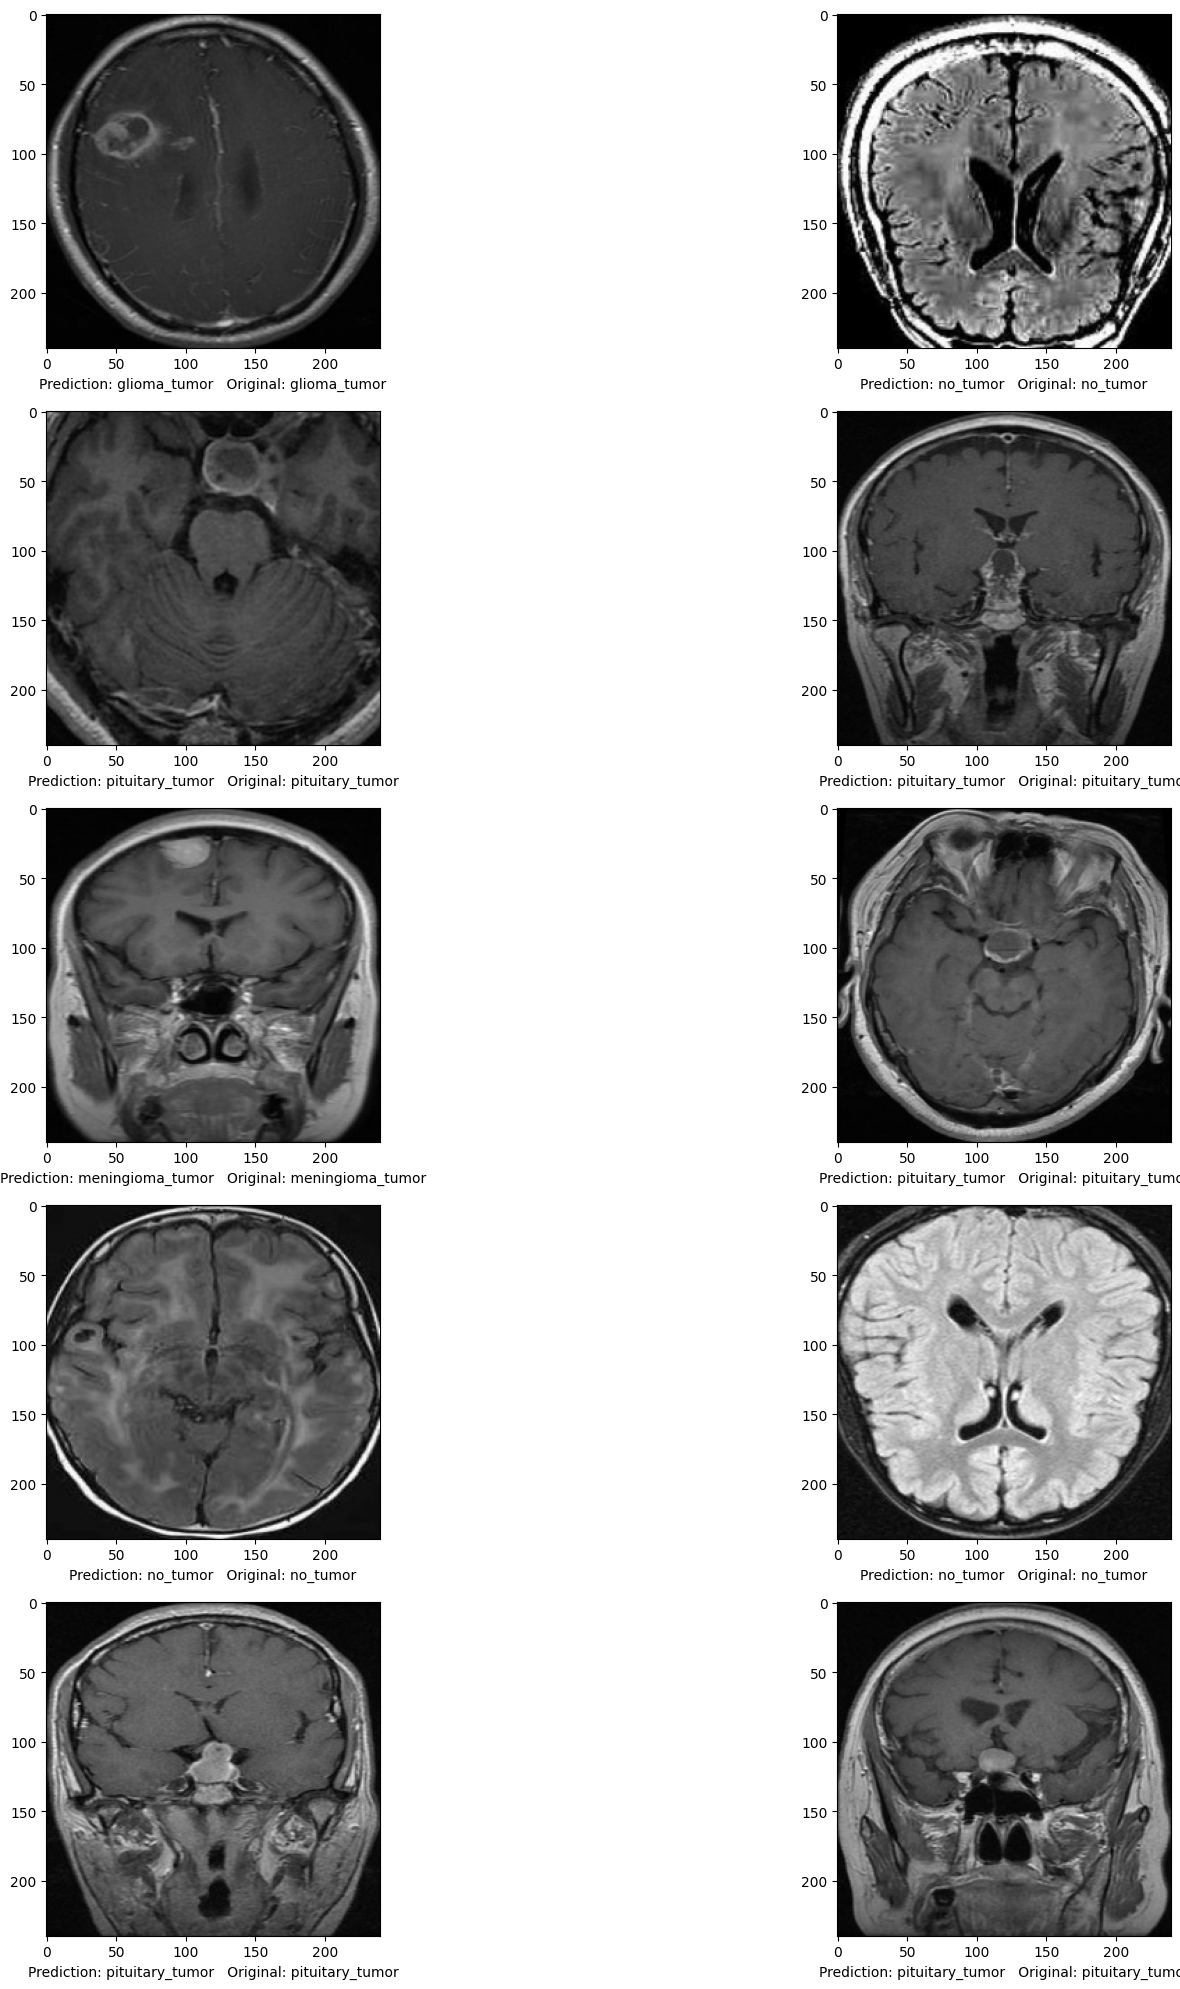

In [154]:
#visualize the results
fig = plt.figure(figsize = (20, 20))
for i in range(10):
    j = random.randint(0, len(image))
    fig.add_subplot(5, 2, i+1)
    plt.xlabel("Prediction: " + prediction[j] +"   Original: " + original[j])
    plt.imshow(image[j])
fig.tight_layout()
plt.show()

In [107]:
last_conv_layer = next(x for x in model.layers[::-1] if isinstance(x, K.layers.Conv2D))
last_conv_layer.name

'top_conv'

In [39]:
#https://github.com/gkeechin/vizgradcam/blob/main/gradcam.py

def VizGradCAM(model, image, interpolant=0.5, plot_results=True):

    """VizGradCAM - Displays GradCAM based on Keras / TensorFlow models
    using the gradients from the last convolutional layer. This function
    should work with all Keras Application listed here:
    https://keras.io/api/applications/
    Parameters:
    model (keras.model): Compiled Model with Weights Loaded
    image: Image to Perform Inference On
    plot_results (boolean): True - Function Plots using PLT
                            False - Returns Heatmap Array
    Returns:
    Heatmap Array?
    """
    #sanity check
    assert (interpolant > 0 and interpolant < 1), "Heatmap Interpolation Must Be Between 0 - 1"

    #STEP 1: Preprocesss image and make prediction using our model
    #input image
    original_img = np.asarray(image, dtype = np.float32)
    #expamd dimension and get batch size
    img = np.expand_dims(original_img, axis=0)
    #predict
    prediction = model.predict(img)
    #prediction index
    prediction_idx = np.argmax(prediction)

    #STEP 2: Create new model
    #specify last convolutional layer
    last_conv_layer = next(x for x in model.layers[::-1] if isinstance(x, K.layers.Conv2D))
    target_layer = model.get_layer(last_conv_layer.name)

    #compute gradient of top predicted class
    with tf.GradientTape() as tape:
        #create a model with original model inputs and the last conv_layer as the output
        gradient_model = Model([model.inputs], [target_layer.output, model.output])
        #pass the image through the base model and get the feature map  
        conv2d_out, prediction = gradient_model(img)
        #prediction loss
        loss = prediction[:, prediction_idx]

    #gradient() computes the gradient using operations recorded in context of this tape
    gradients = tape.gradient(loss, conv2d_out)

    #obtain the output from shape [1 x H x W x CHANNEL] -> [H x W x CHANNEL]
    output = conv2d_out[0]

    #obtain depthwise mean
    weights = tf.reduce_mean(gradients[0], axis=(0, 1))


    #create a 7x7 map for aggregation
    activation_map = np.zeros(output.shape[0:2], dtype=np.float32)
    #multiply weight for every layer
    for idx, weight in enumerate(weights):
        activation_map += weight * output[:, :, idx]
    #resize to image size
    activation_map = cv2.resize(activation_map.numpy(), 
                                (original_img.shape[1], 
                                 original_img.shape[0]))
    #ensure no negative number
    activation_map = np.maximum(activation_map, 0)
    #convert class activation map to 0 - 255
    activation_map = (activation_map - activation_map.min()) / (activation_map.max() - activation_map.min())
    #rescale and convert the type to int
    activation_map = np.uint8(255 * activation_map)


    #convert to heatmap
    heatmap = cv2.applyColorMap(activation_map, cv2.COLORMAP_JET)

    #superimpose heatmap onto image
    original_img = np.uint8((original_img - original_img.min()) / (original_img.max() - original_img.min()) * 255)
    cvt_heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    cvt_heatmap = img_to_array(cvt_heatmap)

    #enlarge plot
    plt.rcParams["figure.dpi"] = 100

    if plot_results == True:
        plt.imshow(np.uint8(original_img * interpolant + cvt_heatmap * (1 - interpolant)))
    else:
        return cvt_heatmap

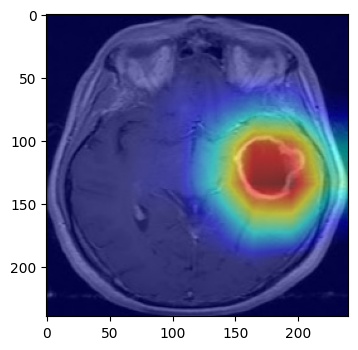

In [40]:
#load image
test_img = cv2.imread("/content/Test-Data/glioma_tumor/4.jpg")

#apply function
VizGradCAM(model, img_to_array(test_img), plot_results=True)

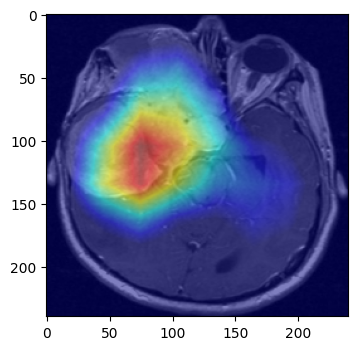

In [41]:
#load image
test_img = cv2.imread("/content/Test-Data/meningioma_tumor/0.jpg")

#apply function
VizGradCAM(model, img_to_array(test_img), plot_results=True)

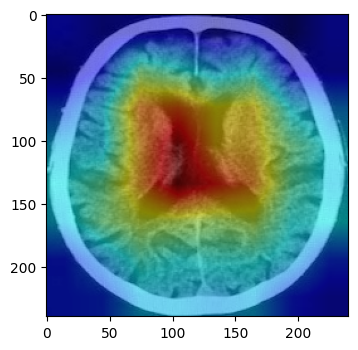

In [42]:
#load image
test_img = cv2.imread("/content/Test-Data/no_tumor/3.jpg")

#apply function
VizGradCAM(model, img_to_array(test_img), plot_results=True)

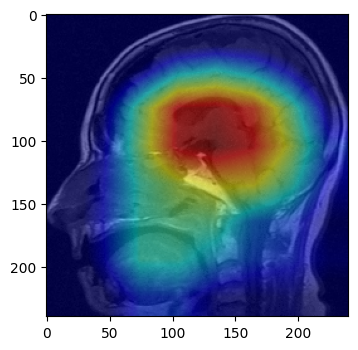

In [43]:
#load image
test_img = cv2.imread("/content/Test-Data/pituitary_tumor/4.jpg")

#apply function
VizGradCAM(model, img_to_array(test_img), plot_results=True)